# Deep Learning: Pixels, Tensors & Color Spaces

If we want a neural network to process visual reality, we must first understand how to mathematically translate the physical phenomenon of *photons* into matrices that PyTorch's Autograd engine can digest.

To a computer, an image is not a picture; it is a massive, multi-dimensional tensor. In this lesson, we will use a real image, rip it apart into its base mathematical matrices, explore the linear algebra of color space conversions, and navigate the architectural memory traps of PyTorch vision pipelines.

Let's set up our PyTorch environment and load our native sample image from `skimage`.

In [18]:
import torch
import torchvision.transforms as transforms
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Vision & Scikit-Image Environment Ready.")

✅ PyTorch Vision & Scikit-Image Environment Ready.


# 1. The Matrix of Sight & IEEE 754 Floating-Point Math

A digital camera sensor converts photons hitting a grid of photodiodes into discrete voltage levels. These voltages are quantized into 8-bit integers (`uint8`), meaning every pixel is assigned a strict whole number between $0$ (absolute darkness) and $255$ (maximum sensor saturation).

If you load a standard image, your computer allocates memory for a matrix $X \in \mathbb{Z}^{H \times W}_{[0, 255]}$.

### The Deep Learning Normalization Mandate

You **cannot** feed `uint8` integers of magnitude $255$ into a Deep Neural Network.
Modern GPUs use IEEE 754 32-bit floating-point precision (`float32`). If you feed a value of $255.0$ into a neural network with randomly initialized weights, the first matrix multiplication will produce massive numbers. Passing these numbers through an activation function (like ReLU) preserves their magnitude, and passing them through Sigmoid/Tanh instantly saturates the neurons, dropping the mathematical derivative (the gradient) to absolute zero.

Before any Deep Learning begins, we must mathematically squash the physical light matrix into a strict continuous range:


$$x_{normalized} = \frac{x_{raw}}{255.0}$$


This projects the domain from $\mathbb{Z}_{[0, 255]}$ to $\mathbb{R}_{[0.0, 1.0]}$, ensuring numerical stability during Backpropagation.

# 2. The Linear Algebra of Color Spaces

Real life is not grayscale. To represent color, we expand our data structure from a 2D matrix to a 3D Tensor containing three primary channels: Red, Green, and Blue (RGB). The mathematical space is defined as $\mathbb{R}^{H \times W \times 3}$.

### The RGB Entanglement Problem

While RGB is exactly how LED monitors emit light, it is highly inefficient for algorithmic analysis. In RGB space, the color of an object and the brightness of the light hitting it are **mathematically entangled**. If a shadow falls across a red apple, *all three* R, G, and B values drop simultaneously.

### The Luminance Equation (Grayscale Conversion)

To isolate physical structure from color, Computer Vision engineers often convert RGB to Grayscale. But you cannot simply average the three channels ($\frac{R+G+B}{3}$). The human eye has vastly different biological sensitivities to different wavelengths of light; we possess exponentially more Green photoreceptors than Blue.

To perfectly mimic human luminance ($Y$), we apply a weighted linear combination (the Rec. 601 standard):


$$Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$

By applying this exact dot product to our tensor, we collapse the 3D RGB space down into a structurally accurate 2D luminance matrix.

# 3. Memory Layouts: CHW vs. HWC

The most catastrophic engineering trap in Computer Vision is **Memory Contiguity** regarding tensor dimensions.

* **HWC (Height, Width, Channels)**: Matplotlib, OpenCV, and `skimage` store image data as `(512, 512, 3)`. In physical computer RAM, this means the Red, Green, and Blue values for pixel (0,0) sit right next to each other in memory. This is called *Interleaved* layout. It is great for drawing pixels on a screen.
* **CHW (Channels, Height, Width)**: PyTorch and cuDNN violently reject HWC. They mandate `(3, 512, 512)`. In RAM, this means the entire Red matrix is stored contiguously, followed by the entire Green matrix. This is called *Planar* layout.

**Why CHW?** GPUs are optimized for SIMD (Single Instruction, Multiple Data) vectorized operations. When PyTorch applies a Convolutional Kernel, it needs to sweep across a single color channel as fast as possible. If the memory is interleaved (HWC), the GPU suffers massive cache misses trying to skip over the Green and Blue bytes. CHW guarantees contiguous memory reads, maximizing PCIe bus throughput.


# 4. Processing Real Images in PyTorch

Let's load the `skimage` astronaut image, run it through PyTorch's transformation pipeline, navigate the dimension trap, and execute the exact mathematics we defined above.

--- 📥 Loading Native skimage Data ---
--- 🚨 Dimension Trap Audit ---
Original Image Size (NumPy): (512, 512, 3) (H, W, C) | Type: uint8
PyTorch Tensor Shape:        torch.Size([3, 512, 512]) (C, H, W) | Type: torch.float32

--- 🔬 Raw Matrix Data (Red Channel, Top-Left 3x3 Patch) ---
[[0.604 0.427 0.247]
 [0.694 0.565 0.443]
 [0.788 0.714 0.659]]


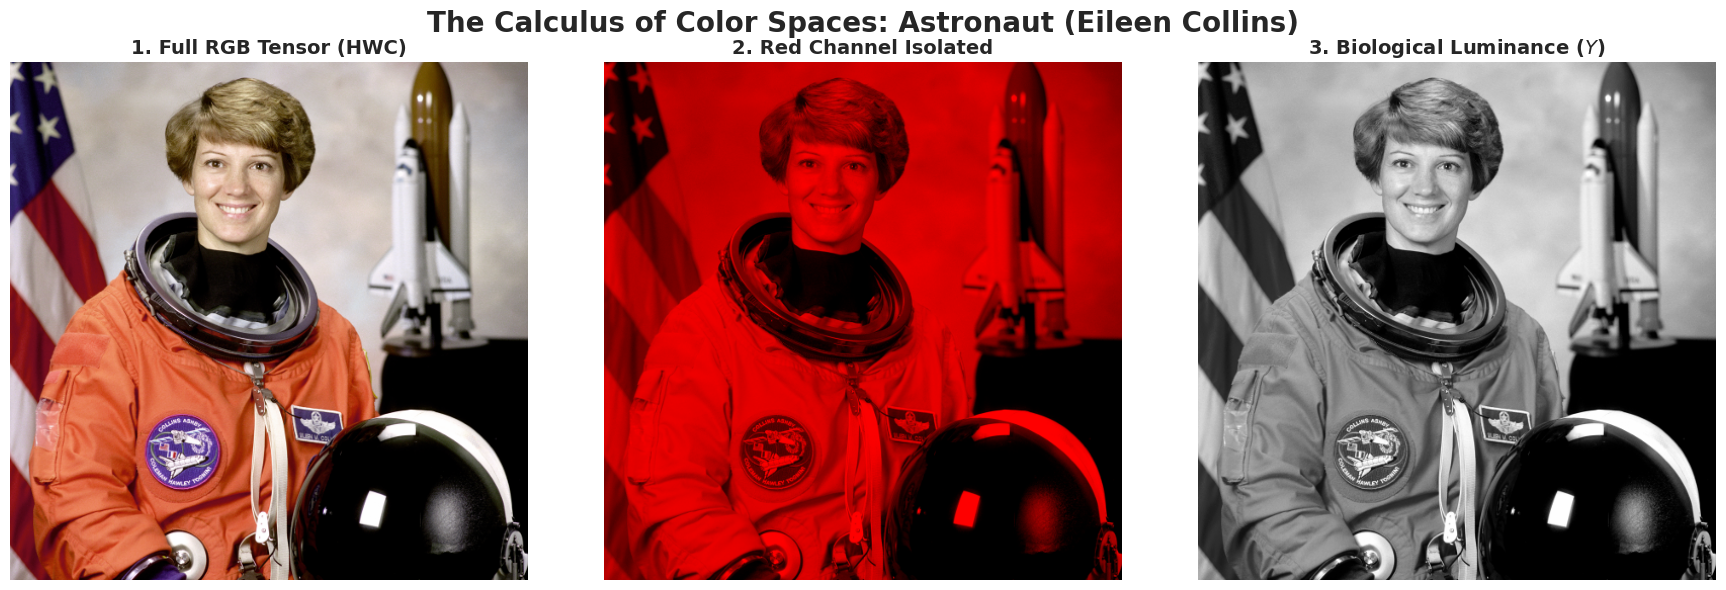

--- 💡 Engineering Insight ---
Observe the Red Channel plot. Notice the American flag patch on her shoulder and the orange launch suit. In the Red isolated matrix, those specific areas contain values near 1.0 (bright red/white). The blue background behind her, however, contains almost zero red light and appears pitch black. When we execute the Luminance equation, the network seamlessly fuses these 3D channel disparities into a perfect 2D representation of physical structural lighting.


In [23]:
# 1. Fetch the Native Scikit-Image Sample (Guaranteed offline and robust)
print("--- 📥 Loading Native skimage Data ---")
numpy_img = data.astronaut() # Returns a NumPy array of type uint8 in HWC format

# 2. PyTorch Transformation Pipeline
# transforms.ToTensor() automatically executes:
# A. Conversion from uint8 to float32.
# B. Normalization: x / 255.0
# C. Memory Reallocation: HWC -> CHW
transform = transforms.ToTensor()
img_tensor = transform(numpy_img)

print("--- 🚨 Dimension Trap Audit ---")
print(f"Original Image Size (NumPy): {numpy_img.shape} (H, W, C) | Type: {numpy_img.dtype}")
print(f"PyTorch Tensor Shape:        {img_tensor.shape} (C, H, W) | Type: {img_tensor.dtype}\n")

# Let's peek at the raw, normalized matrix values
# We slice a tiny 3x3 patch from the top-left corner of the Red Channel
print("--- 🔬 Raw Matrix Data (Red Channel, Top-Left 3x3 Patch) ---")
print(img_tensor[0, 0:3, 0:3].numpy().round(3))

# 3. Channel Isolation Mathematics
# To show ONLY red visually, we create a copy and mathematically zero-out the Green and Blue matrices.
red_tensor = img_tensor.clone()
red_tensor[1, :, :] = 0.0 # Zero-out Green
red_tensor[2, :, :] = 0.0 # Zero-out Blue

# 4. The Luminance Dot Product (Grayscale Calculation)
# We apply Y = 0.299R + 0.587G + 0.114B
# Extract the individual 2D matrices:
R = img_tensor[0, :, :]
G = img_tensor[1, :, :]
B = img_tensor[2, :, :]

# Execute the linear combination
grayscale_matrix = (0.299 * R) + (0.587 * G) + (0.114 * B)
# Note: The output is a 2D tensor [H, W] because we collapsed the color dimension!

# 5. The Reversal (For Visualization)
# Matplotlib CANNOT read CHW tensors. We must mathematically .permute() 
# the dimensions back to HWC (moving dimension 0 to the end) to plot them.
def prepare_for_plot(tensor):
    return tensor.permute(1, 2, 0).numpy()

# 6. Visualizing the Mathematical Transformations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("The Calculus of Color Spaces: Astronaut (Eileen Collins)", fontsize=20, fontweight='bold')

# Plot A: Full RGB Tensor
axes[0].imshow(prepare_for_plot(img_tensor))
axes[0].set_title("1. Full RGB Tensor (HWC)", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot B: Red Channel Isolated
axes[1].imshow(prepare_for_plot(red_tensor))
axes[1].set_title("2. Red Channel Isolated", fontweight='bold', fontsize=14)
axes[1].axis('off')

# Plot C: Grayscale (Luminance Equation)
# We use cmap='gray' because the tensor is purely 2D now.
axes[2].imshow(grayscale_matrix.numpy(), cmap='gray')
axes[2].set_title("3. Biological Luminance ($Y$)", fontweight='bold', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("--- 💡 Engineering Insight ---")
print("Observe the Red Channel plot. Notice the American flag patch on her shoulder and the orange launch suit. In the Red isolated matrix, those specific areas contain values near 1.0 (bright red/white). The blue background behind her, however, contains almost zero red light and appears pitch black. When we execute the Luminance equation, the network seamlessly fuses these 3D channel disparities into a perfect 2D representation of physical structural lighting.")